# Chunk 策略对比分析

本项目实践了五种 Chunk策略

1. **fixed** - 固定大小切分（RecursiveCharacterTextSplitter）
2. **sentence** - 基于句子的切分
3. **semantic** - 语义切分（基于嵌入相似度）
4. **hierarchical** - 层次化切分（先段落后句子）
5. **sliding_window** - 滑动窗口切分


In [ ]:
import sys
from pathlib import Path
from dotenv import load_dotenv

# 添加项目路径
project_root = Path().resolve().parent
sys.path.insert(0, str(project_root / "src"))

# 加载环境变量（从 configs/env 加载）
env_path = project_root / "configs" / "env"
if env_path.exists():
    load_dotenv(env_path)

from langchain_core.documents import Document
from wxchatrag.chunking import ChunkStrategy


d:\worksoft\Anaconda3\envs\llmtorch\Lib\site-packages\langchain_core\_api\deprecation.py:25: UserWarning: Core Pydantic V1 functionality isn't compatible with Python 3.14 or greater.
  from pydantic.v1.fields import FieldInfo as FieldInfoV1
d:\worksoft\Anaconda3\envs\llmtorch\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 准备测试文档

加载第一个 PDF 作为测试用例。


In [ ]:
# 加载第一个 PDF 作为测试文档
from wxchatrag.settings import get_settings
from wxchatrag.wxhub_loader import iter_pdf_paths, load_pdf_documents, build_channel_indexes

# 获取配置
settings = get_settings()
wxhub_root = settings.wxhub_root
glob_pattern = settings.pdf_glob_pattern or f"*/{settings.pdf_subdir_name}/*.pdf"

print(f"WXhub 根目录: {wxhub_root}")
print(f"PDF 匹配模式: {glob_pattern}")

# 获取所有 PDF 路径
pdf_paths = iter_pdf_paths(wxhub_root, glob_pattern)

if not pdf_paths:
    print("⚠ 警告: 未找到 PDF 文件，使用示例文本")
    sample_text = """
        人工智能（AI）是计算机科学的一个分支，旨在创建能够执行通常需要人类智能的任务的系统。

        机器学习是人工智能的一个子集，它使计算机能够从数据中学习，而无需明确编程。深度学习是机器学习的一个子集，它使用神经网络来模拟人脑的工作方式。

        自然语言处理（NLP）是人工智能的另一个重要领域，它使计算机能够理解、解释和生成人类语言。

        计算机视觉是人工智能的一个分支，它使计算机能够从图像和视频中提取有意义的信息。

        强化学习是一种机器学习方法，其中智能体通过与环境交互来学习最优行为策略。

        这些技术正在改变我们生活的方方面面，从医疗诊断到自动驾驶汽车，从智能助手到推荐系统。
        """
    test_doc = Document(
        page_content=sample_text.strip(),
        metadata={"source": "test_document", "title": "AI 概述"}
    )
else:
    # 加载第一个 PDF
    first_pdf_path = pdf_paths[0]
    print(f"\n✓ 找到 {len(pdf_paths)} 个 PDF 文件")
    print(f"✓ 使用第一个 PDF: {first_pdf_path.name}")
    print(f"  完整路径: {first_pdf_path}")
    
    # 加载 PDF 文档
    channel_indexes = build_channel_indexes(wxhub_root)
    pdf_docs = load_pdf_documents(
        pdf_paths=[first_pdf_path],
        channel_indexes=channel_indexes
    )
    
    if pdf_docs:
        # 合并所有页面的内容为一个文档
        # 注意：load_pdf_documents 已经自动清理了文本（合并多余的换行）
        all_content = "\n\n".join([doc.page_content for doc in pdf_docs])
        
        # 使用第一个文档的元数据
        test_doc = Document(
            page_content=all_content,
            metadata=pdf_docs[0].metadata
        )
        print(f"\n✓ PDF 加载成功")
        print(f"  标题: {test_doc.metadata.get('title', 'N/A')}")
        print(f"  公众号: {test_doc.metadata.get('channel', 'N/A')}")
        print(f"  日期: {test_doc.metadata.get('date', 'N/A')}")
        print(f"  页数: {len(pdf_docs)}")
    else:
        print("⚠ 警告: PDF 加载失败，使用示例文本")
        test_doc = Document(
            page_content="示例文本",
            metadata={"source": "test_document", "title": "示例"}
        )

print(f"\n文档长度: {len(test_doc.page_content)} 字符")
print(f"文档内容预览:\n{test_doc.page_content[:2000]}...")


WXhub 根目录: F:\AIhub\Agent-RAG\WXdown-RAG\data\WXhub
PDF 匹配模式: */pdf/*.pdf

✓ 找到 1018 个 PDF 文件
✓ 使用第一个 PDF: 2026-02-19-人工智能时代真正重要的技能：你的品味.pdf
  完整路径: F:\AIhub\Agent-RAG\WXdown-RAG\data\WXhub\AI寒武纪\pdf\2026-02-19-人工智能时代真正重要的技能：你的品味.pdf

✓ PDF 加载成功
  标题: 人工智能时代真正重要的技能：你的品味
  公众号: AI寒武纪
  日期: 2026-02-19
  页数: 8

文档长度: 9469 字符
文档内容预览:
人工智能时代真正重要的技能：你的品味2026 年 2 月 19 日 12:05 AI 寒武纪 ↑ 阅读之前记得关注 + 星标  ️ ，  ，每天才能第一时间接收到更新 在人工智能时代，品味将变得更加重要。当任何人都能制作任何东西时，真正的区别在 在人工智能时代，品味将变得更加重要。当任何人都能制作任何东西时，真正的区别在 于你选择制作什么 于你选择制作什么 Paul Graham （ YC 创始人，著名技术作家） 24 年前这篇关于品味的文章，我觉得非常有意 思，分享给大家，现在 AI 发展一日千里，几乎每天都有热点刷屏，但对我们个人真正重要的是 什么？这篇文章或许能给你答案 创造者的品味 创造者的品味 (Taste for Makers) 2002 年 年 2 月 月 “…… 哥白尼对 [ 偏心匀速点 ] 的美学异议，是他摒弃托勒密体系的一个根本动机 ……”—— 托马斯 · 库恩，《哥白尼革命》 “ 我们所有人都受过凯利 · 约翰逊（ Kelly Johnson ）的训练，并狂热地笃信他的坚持：一架看 起来漂亮的飞机，飞起来也一定漂亮。 ” —— 本 · 里奇，《臭鼬工厂》 “ 美是首要标准：丑陋的数学在世上无容身之地。 ” —— G.H. 哈代，《一个数学家的辩白》

最近我和一位在麻省理工学院（ MIT ）任教的朋友聊天。他所在的领域目前非常热门，每年都 会被想读研的学生申请信淹没。 “ 他们中很多人看起来很聪明， ” 他说， “ 但我看不出他们是否 有任何形式的 品味 品味 。 ” 品味。如今你很少听到这

## 对比不同策略

使用相同的参数测试所有策略。

语义切分采用当前项目的最佳实践：
- 使用 `mixed` 分句模式，兼容中文、英文和换行
- 显式指定 `percentile` 阈值算法
- 优先复用项目配置，必要时仅对语义切分追加专属参数


In [ ]:
import os

# 配置参数
chunk_size = 200
chunk_overlap = 50

# 读取项目配置
from wxchatrag.settings import get_settings

settings = get_settings()

# 从配置读取语义切分参数；最佳实践是显式使用 mixed 分句模式
semantic_embedding_mode = os.getenv("SEMANTIC_EMBEDDING_MODE", settings.semantic_embedding_mode)
semantic_embedding_model_name = os.getenv(
    "SEMANTIC_EMBEDDING_MODEL_NAME",
    settings.semantic_embedding_model_name
)
semantic_sentence_split_mode = os.getenv(
    "SEMANTIC_SENTENCE_SPLIT_MODE",
    settings.semantic_sentence_split_mode,
)
semantic_sentence_split_regex = os.getenv(
    "SEMANTIC_SENTENCE_SPLIT_REGEX",
    settings.semantic_sentence_split_regex,
)
semantic_breakpoint_threshold_type = "percentile"

print("语义切分配置:")
print(f"  embedding 模式: {semantic_embedding_mode}")
print(f"  embedding 模型: {semantic_embedding_model_name}")
print(f"  分句模式: {semantic_sentence_split_mode}")
print(f"  自定义 regex: {semantic_sentence_split_regex or '(使用内置规则)'}")
print(f"  阈值算法: {semantic_breakpoint_threshold_type}")

# 语义切分通过 ChunkStrategy 按需自动创建 embeddings
embeddings = None


语义切分配置:
  embedding 模式: local
  embedding 模型: BAAI/bge-small-zh-v1.5
  分句模式: mixed
  自定义 regex: (使用内置规则)
  阈值算法: percentile


In [ ]:
from wxchatrag.chunking import ChunkStrategy

# 测试所有策略（包括语义切分）
strategies = ["fixed", "sentence", "hierarchical", "sliding_window", "semantic"]

results = {}
strategy_configs = {}

for strategy in strategies:
    print(f"\n{'='*60}")
    print(f"测试策略: {strategy}")
    print(f"{'='*60}")

    try:
        kwargs = {
            "chunk_size": chunk_size,
            "chunk_overlap": chunk_overlap,
        }

        # 仅对语义切分追加专属参数，避免把无关参数传给其他 splitter
        if strategy == "semantic":
            kwargs.update(
                {
                    "embeddings": embeddings,
                    "semantic_embedding_mode": semantic_embedding_mode,
                    "embedding_model_name": semantic_embedding_model_name,
                    "sentence_split_mode": semantic_sentence_split_mode,
                    "sentence_split_regex": semantic_sentence_split_regex or None,
                    "breakpoint_threshold_type": semantic_breakpoint_threshold_type,
                    "similarity_threshold": settings.semantic_threshold,
                }
            )

        chunks = ChunkStrategy.split_documents(
            documents=[test_doc],
            strategy=strategy,
            **kwargs,
        )

        results[strategy] = chunks
        strategy_configs[strategy] = kwargs
        print(f"✓ 成功生成 {len(chunks)} 个块")

        if strategy == "semantic" and chunks:
            print(f"  分句模式: {chunks[0].metadata.get('sentence_split_mode', 'unknown')}")
            print(f"  分句 regex: {chunks[0].metadata.get('sentence_split_regex', 'unknown')}")
            print(f"  阈值算法: {semantic_breakpoint_threshold_type}")

        # 显示前3个块的信息
        for i, chunk in enumerate(chunks[:3], 1):
            print(f"\n块 {i}:")
            print(f"  长度: {len(chunk.page_content)} 字符")
            print(f"  策略: {chunk.metadata.get('chunk_strategy', 'unknown')}")
            if strategy == 'semantic':
                print(f"  分句模式: {chunk.metadata.get('sentence_split_mode', 'unknown')}")
            print(f"  内容预览: {chunk.page_content}...")

    except Exception as e:
        print(f"✗ 失败: {e}")
        import traceback
        traceback.print_exc()



测试策略: fixed
✓ 成功生成 65 个块

块 1:
  长度: 141 字符
  策略: fixed_size
  内容预览: 人工智能时代真正重要的技能：你的品味2026 年 2 月 19 日 12:05 AI 寒武纪 ↑ 阅读之前记得关注 + 星标  ️ ，  ，每天才能第一时间接收到更新 在人工智能时代，品味将变得更加重要。当任何人都能制作任何东西时，真正的区别在 在人工智能时代，品味将变得更加重要...

块 2:
  长度: 139 字符
  策略: fixed_size
  内容预览: 。当任何人都能制作任何东西时，真正的区别在 于你选择制作什么 于你选择制作什么 Paul Graham （ YC 创始人，著名技术作家） 24 年前这篇关于品味的文章，我觉得非常有意 思，分享给大家，现在 AI 发展一日千里，几乎每天都有热点刷屏，但对我们个人真正重要的是 什么...

块 3:
  长度: 196 字符
  策略: fixed_size
  内容预览: ？这篇文章或许能给你答案 创造者的品味 创造者的品味 (Taste for Makers) 2002 年 年 2 月 月 “…… 哥白尼对 [ 偏心匀速点 ] 的美学异议，是他摒弃托勒密体系的一个根本动机 ……”—— 托马斯 · 库恩，《哥白尼革命》 “ 我们所有人都受过凯利 · 约翰逊（ Kelly Johnson ）的训练，并狂热地笃信他的坚持：一架看 起来漂亮的飞机，飞起来也一定漂亮...

测试策略: sentence
✓ 成功生成 60 个块

块 1:
  长度: 140 字符
  策略: sentence_based
  内容预览: 人工智能时代真正重要的技能：你的品味2026 年 2 月 19 日 12:05 AI 寒武纪 ↑ 阅读之前记得关注 + 星标  ️ ，  ，每天才能第一时间接收到更新 在人工智能时代，品味将变得更加重要当任何人都能制作任何东西时，真正的区别在 在人工智能时代，品味将变得更加重要...

块 2:
  长度: 176 字符
  策略: sentence_based
  内容预览: 当任何人都能制作任何东西时，真正的区别在 在人工智能时代，品味将变得更加重要当任何人都能制作任何东西时，真正的区别在 于你选择制作什么 于你选择制作什么 Paul Gra

Loading weights: 100%|██████████| 71/71 [00:00<00:00, 1104.72it/s, Materializing param=pooler.dense.weight]                              
BertModel LOAD REPORT from: BAAI/bge-small-zh-v1.5
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


✓ 成功生成 13 个块
  分句模式: mixed
  分句 regex: (?<=[。！？；])|(?<=[.?!])\s+|\n+
  阈值算法: percentile

块 1:
  长度: 535 字符
  策略: semantic
  分句模式: mixed
  内容预览: 人工智能时代真正重要的技能：你的品味2026 年 2 月 19 日 12:05 AI 寒武纪 ↑ 阅读之前记得关注 + 星标  ️ ，  ，每天才能第一时间接收到更新 在人工智能时代，品味将变得更加重要。 当任何人都能制作任何东西时，真正的区别在 在人工智能时代，品味将变得更加重要。 当任何人都能制作任何东西时，真正的区别在 于你选择制作什么 于你选择制作什么 Paul Graham （ YC 创始人，著名技术作家） 24 年前这篇关于品味的文章，我觉得非常有意 思，分享给大家，现在 AI 发展一日千里，几乎每天都有热点刷屏，但对我们个人真正重要的是 什么？ 这篇文章或许能给你答案 创造者的品味 创造者的品味 (Taste for Makers) 2002 年 年 2 月 月 “…… 哥白尼对 [ 偏心匀速点 ] 的美学异议，是他摒弃托勒密体系的一个根本动机 ……”—— 托马斯 · 库恩，《哥白尼革命》 “ 我们所有人都受过凯利 · 约翰逊（ Kelly Johnson ）的训练，并狂热地笃信他的坚持：一架看 起来漂亮的飞机，飞起来也一定漂亮。  ” —— 本 · 里奇，《臭鼬工厂》 “ 美是首要标准：丑陋的数学在世上无容身之地。  ” —— G.H....

块 2:
  长度: 2649 字符
  策略: semantic
  分句模式: mixed
  内容预览: 哈代，《一个数学家的辩白》 最近我和一位在麻省理工学院（ MIT ）任教的朋友聊天。 他所在的领域目前非常热门，每年都 会被想读研的学生申请信淹没。  “ 他们中很多人看起来很聪明， ” 他说， “ 但我看不出他们是否 有任何形式的 品味 品味 。  ” 品味。 如今你很少听到这个词了。 然而，无论我们如何称呼它，我们仍然需要这个词背后的概 念。 我朋友的意思是，他想要的学生不仅仅是优秀的技术人员，还要能利用他们的技术知识设 计出美妙东西的人。  数学家将好的工作称为 “ 美 ” ，不管是现在还是过去，科学家、工程

## 统计分析

对比不同策略的统计指标。


In [ ]:
import pandas as pd

# 配置pandas显示选项，确保中文和数值正确显示
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)
pd.set_option('display.unicode.ambiguous_as_wide', True)
pd.set_option('display.unicode.east_asian_width', True)
pd.set_option('display.precision', 2)
import numpy as np

# 收集统计数据
stats = []

for strategy, chunks in results.items():
    chunk_sizes = [len(chunk.page_content) for chunk in chunks]
    
    stats.append({
        "策略": strategy,
        "块数量": len(chunks),
        "平均长度": np.mean(chunk_sizes),
        "中位数长度": np.median(chunk_sizes),
        "最小长度": np.min(chunk_sizes),
        "最大长度": np.max(chunk_sizes),
        "标准差": np.std(chunk_sizes),
    })

df_stats = pd.DataFrame(stats)
print("\n统计对比表:")
print(df_stats.to_string(index=False))



统计对比表:
          策略  块数量  平均长度  中位数长度  最小长度  最大长度  标准差
         fixed      65    168.82       178.0        33       200   31.08
      sentence      60    178.20       183.0       132       200   19.43
  hierarchical      62    170.31       177.5        62       199   28.10
sliding_window      64    196.69       200.0        19       200   22.71
      semantic      13    750.92       624.0       209      2649  593.11


## 可视化对比

可视化不同策略的块大小分布。


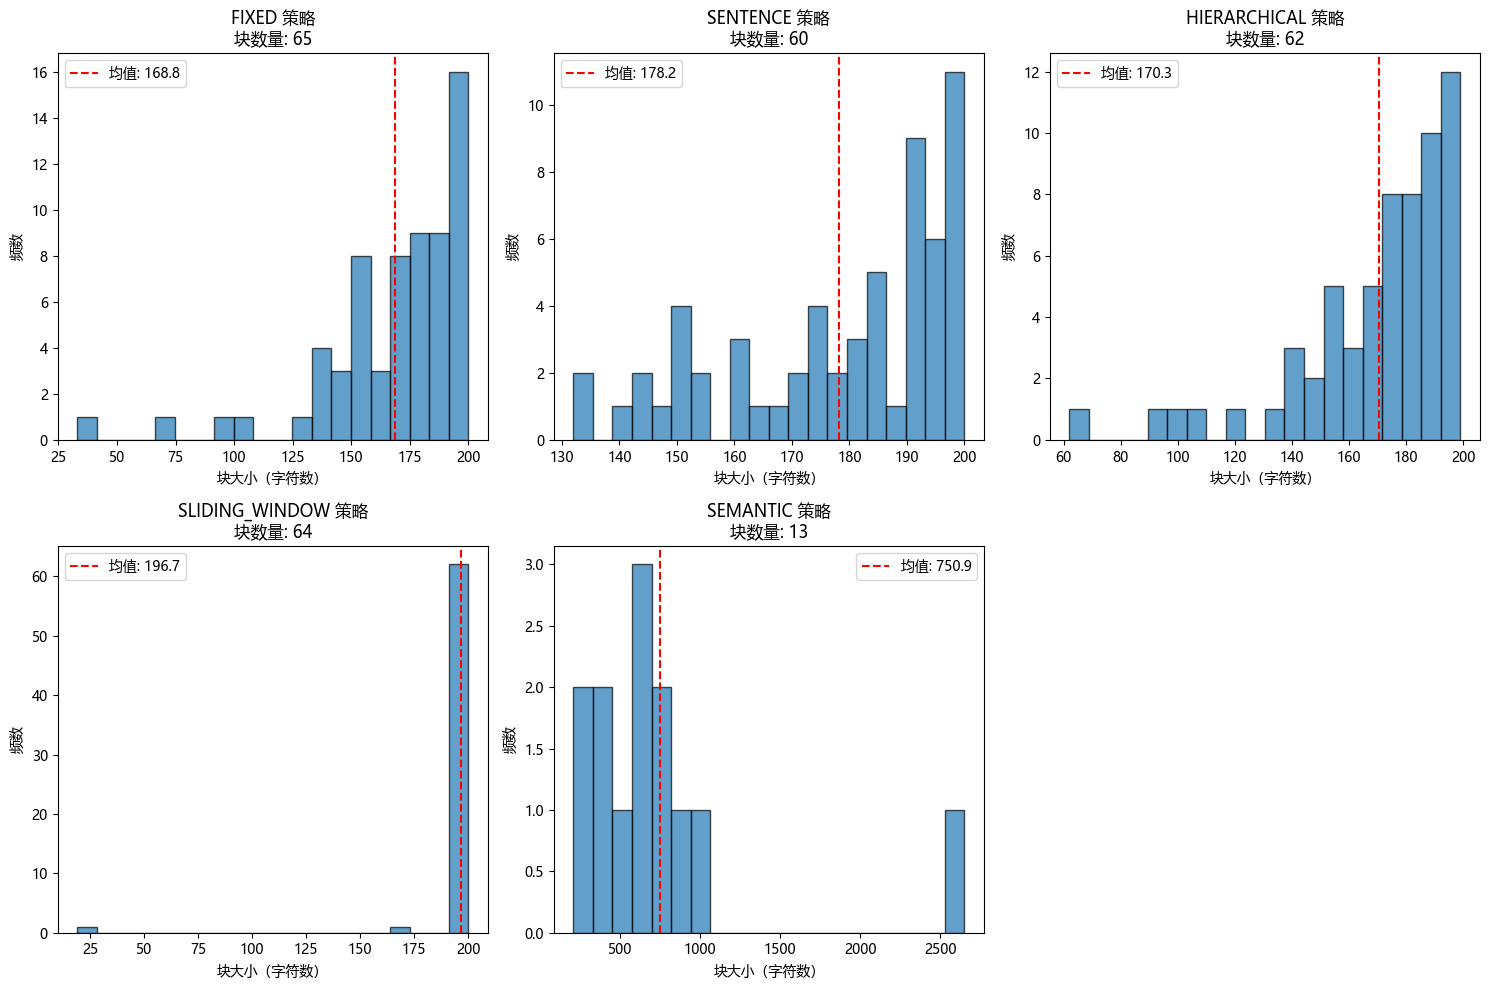

In [ ]:
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['font.sans-serif'] = ['Microsoft YaHei', 'SimHei', 'SimSun', 'Arial Unicode MS']  # 支持中文，使用更兼容的字体列表
matplotlib.rcParams['axes.unicode_minus'] = False

# 绘制块大小分布
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()

for idx, (strategy, chunks) in enumerate(results.items()):
    if idx >= len(axes):
        break
    
    chunk_sizes = [len(chunk.page_content) for chunk in chunks]
    
    axes[idx].hist(chunk_sizes, bins=20, alpha=0.7, edgecolor='black')
    axes[idx].set_title(f"{strategy.upper()} 策略\n块数量: {len(chunks)}")
    axes[idx].set_xlabel("块大小（字符数）")
    axes[idx].set_ylabel("频数")
    axes[idx].axvline(np.mean(chunk_sizes), color='r', linestyle='--', label=f'均值: {np.mean(chunk_sizes):.1f}')
    axes[idx].legend()

# 隐藏多余的子图
for idx in range(len(results), len(axes)):
    axes[idx].axis('off')

plt.tight_layout()
plt.show()


## 原文片段对齐对比

针对文档开头部分，对比各策略的切分效果。这是最直观的方式来判断切分质量。


In [ ]:
# 选择文档开头部分进行对比（前1500字符，包含标题、引言、章节标题和正文开头）
# 这个区域结构清晰，适合观察不同策略的切分效果
start_pos = 0
end_pos = 1500

original_snippet = test_doc.page_content[start_pos:end_pos]
print("="*80)
print("原文片段（位置 0-1500 字符）:")
print("="*80)
print(original_snippet)
print("\n" + "="*80)
print(f"片段长度: {len(original_snippet)} 字符")
print("="*80)

# 辅助函数：根据chunk的start_index或window_start找到覆盖指定区间的块
def find_chunks_in_range(chunks, start_pos, end_pos, strategy_name):
    """找到覆盖指定原文区间的所有chunks"""
    covering_chunks = []
    
    for i, chunk in enumerate(chunks):
        chunk_start = None
        chunk_end = None
        
        # 不同策略的元数据字段不同
        if 'start_index' in chunk.metadata:
            # fixed策略有start_index
            chunk_start = chunk.metadata['start_index']
            chunk_end = chunk_start + len(chunk.page_content)
        elif 'window_start' in chunk.metadata:
            # sliding_window策略有window_start和window_end
            chunk_start = chunk.metadata['window_start']
            chunk_end = chunk.metadata['window_end']
        else:
            # 其他策略需要累加计算位置
            # 这里简化处理：如果chunk内容与原文片段有重叠就认为覆盖
            chunk_text = chunk.page_content
            if chunk_text in test_doc.page_content:
                # 找到chunk在原文中的位置
                pos = test_doc.page_content.find(chunk_text)
                if pos != -1:
                    chunk_start = pos
                    chunk_end = pos + len(chunk_text)
        
        # 判断是否覆盖目标区间（有交集）
        if chunk_start is not None and chunk_end is not None:
            if not (chunk_end <= start_pos or chunk_start >= end_pos):
                covering_chunks.append({
                    'index': i + 1,
                    'chunk': chunk,
                    'start': chunk_start,
                    'end': chunk_end,
                    'overlap_start': max(chunk_start, start_pos),
                    'overlap_end': min(chunk_end, end_pos)
                })
    
    return covering_chunks

# 对每个策略，找出覆盖开头片段的chunks
print("\n\n各策略对开头片段的切分效果对比：\n")
print("="*80)

for strategy in strategies:
    if strategy not in results:
        continue
    
    chunks = results[strategy]
    covering = find_chunks_in_range(chunks, start_pos, end_pos, strategy)
    
    print(f"\n【{strategy.upper()} 策略】")
    print(f"覆盖该片段的块数量: {len(covering)}")
    print("-" * 80)
    
    for item in covering:
        chunk = item['chunk']
        idx = item['index']
        chunk_start = item['start']
        chunk_end = item['end']
        
        print(f"\n块 {idx} (原文位置 [{chunk_start}, {chunk_end}))")
        print(f"块长度: {len(chunk.page_content)} 字符")
        
        # 显示块内容（如果太长则截断）
        content_preview = chunk.page_content
        if len(content_preview) > 300:
            content_preview = content_preview[:300] + "..."
        print(f"内容预览:\n{content_preview}")
        print("-" * 80)
    
    print("\n")


原文片段（位置 0-1500 字符）:
人工智能时代真正重要的技能：你的品味2026 年 2 月 19 日 12:05 AI 寒武纪 ↑ 阅读之前记得关注 + 星标  ️ ，  ，每天才能第一时间接收到更新 在人工智能时代，品味将变得更加重要。当任何人都能制作任何东西时，真正的区别在 在人工智能时代，品味将变得更加重要。当任何人都能制作任何东西时，真正的区别在 于你选择制作什么 于你选择制作什么 Paul Graham （ YC 创始人，著名技术作家） 24 年前这篇关于品味的文章，我觉得非常有意 思，分享给大家，现在 AI 发展一日千里，几乎每天都有热点刷屏，但对我们个人真正重要的是 什么？这篇文章或许能给你答案 创造者的品味 创造者的品味 (Taste for Makers) 2002 年 年 2 月 月 “…… 哥白尼对 [ 偏心匀速点 ] 的美学异议，是他摒弃托勒密体系的一个根本动机 ……”—— 托马斯 · 库恩，《哥白尼革命》 “ 我们所有人都受过凯利 · 约翰逊（ Kelly Johnson ）的训练，并狂热地笃信他的坚持：一架看 起来漂亮的飞机，飞起来也一定漂亮。 ” —— 本 · 里奇，《臭鼬工厂》 “ 美是首要标准：丑陋的数学在世上无容身之地。 ” —— G.H. 哈代，《一个数学家的辩白》

最近我和一位在麻省理工学院（ MIT ）任教的朋友聊天。他所在的领域目前非常热门，每年都 会被想读研的学生申请信淹没。 “ 他们中很多人看起来很聪明， ” 他说， “ 但我看不出他们是否 有任何形式的 品味 品味 。 ” 品味。如今你很少听到这个词了。然而，无论我们如何称呼它，我们仍然需要这个词背后的概 念。我朋友的意思是，他想要的学生不仅仅是优秀的技术人员，还要能利用他们的技术知识设 计出美妙东西的人。 数学家将好的工作称为 “ 美 ” ，不管是现在还是过去，科学家、工程师、音乐家、建筑师、设计 师、作家和画家也都是如此。他们使用同一个词仅仅是巧合吗？还是说他们的意指确实存在某 种重叠？如果有重叠，我们能否利用一个领域关于 “ 美 ” 的发现来帮助另一个领域？ 对于我们这些设计事物的人来说，这些不仅仅是理论问题。如果确实存在 “ 美 ” 这种东西，我们 需要能够识别它。我们需要好的品味来制造好的东西。与其将 “ 美 ” 视为一个虚无缥缈的抽象概 念 ——

## 冗余度统计

计算各策略的冗余系数（块文本总长度 / 原文长度），反映重叠程度。


In [ ]:
# 计算冗余度统计
redundancy_stats = []
original_length = len(test_doc.page_content)

for strategy, chunks in results.items():
    total_chunk_length = sum(len(chunk.page_content) for chunk in chunks)
    redundancy_ratio = total_chunk_length / original_length if original_length > 0 else 0
    
    redundancy_stats.append({
        "策略": strategy,
        "原文长度": original_length,
        "块文本总长度": total_chunk_length,
        "冗余系数": f"{redundancy_ratio:.3f}",
        "平均重叠率": f"{(redundancy_ratio - 1) * 100:.1f}%" if redundancy_ratio > 1 else "0%"
    })

df_redundancy = pd.DataFrame(redundancy_stats)
print("\n冗余度统计表:")
print(df_redundancy.to_string(index=False))

print("\n说明:")
print("- 冗余系数 = 块文本总长度 / 原文长度")
print("- 冗余系数 > 1 表示有重叠，越大表示重叠越多")
print("- sliding_window 通常冗余系数最高（因为固定重叠）")
print("- semantic 通常冗余系数接近 1（语义切分通常不重叠）")



冗余度统计表:
          策略  原文长度  块文本总长度 冗余系数 平均重叠率
         fixed      9469         10973    1.159      15.9%
      sentence      9469         10692    1.129      12.9%
  hierarchical      9469         10559    1.115      11.5%
sliding_window      9469         12588    1.329      32.9%
      semantic      9469          9762    1.031       3.1%

说明:
- 冗余系数 = 块文本总长度 / 原文长度
- 冗余系数 > 1 表示有重叠，越大表示重叠越多
- sliding_window 通常冗余系数最高（因为固定重叠）
- semantic 通常冗余系数接近 1（语义切分通常不重叠）


## 交互式块浏览

使用交互式控件浏览不同策略的切分结果，可以快速切换策略和块索引。


In [ ]:
try:
    import ipywidgets as widgets
    from IPython.display import display, clear_output
    
    # 创建交互式控件
    strategy_dropdown = widgets.Dropdown(
        options=list(results.keys()),
        value="fixed",
        description="策略:",
        style={'description_width': 'initial'}
    )
    
    # 动态更新滑块的最大值
    max_chunks = max(len(chunks) for chunks in results.values())
    index_slider = widgets.IntSlider(
        value=1,
        min=1,
        max=max_chunks,
        step=1,
        description="块索引:",
        style={'description_width': 'initial'}
    )
    
    output = widgets.Output()
    
    def update_slider_max(strategy):
        """根据选择的策略更新滑块最大值"""
        if strategy in results:
            max_val = len(results[strategy])
            index_slider.max = max_val
            if index_slider.value > max_val:
                index_slider.value = max_val
    
    def show_chunk(strategy, index):
        """显示指定策略和索引的chunk"""
        with output:
            clear_output(wait=True)
            if strategy not in results:
                print(f"策略 '{strategy}' 不存在")
                return
            
            chunks = results[strategy]
            if not (1 <= index <= len(chunks)):
                print(f"索引超出范围: {index} (总共 {len(chunks)} 个块)")
                return
            
            chunk = chunks[index - 1]
            
            print("="*80)
            print(f"{strategy.upper()} 策略 - 块 {index}/{len(chunks)}")
            print("="*80)
            print(f"\n长度: {len(chunk.page_content)} 字符")
            
            # 显示位置信息（如果有）
            if 'start_index' in chunk.metadata:
                print(f"原文位置: [{chunk.metadata['start_index']}, {chunk.metadata['start_index'] + len(chunk.page_content)})")
            elif 'window_start' in chunk.metadata:
                print(f"窗口位置: [{chunk.metadata['window_start']}, {chunk.metadata['window_end']})")
            
            # 显示关键元数据
            key_metadata = {}
            for key in ['chunk_strategy', 'chunk_size', 'chunk_overlap', 
                       'sentence_split_mode', 'chunk_level', 'paragraph_index']:
                if key in chunk.metadata:
                    key_metadata[key] = chunk.metadata[key]
            
            if key_metadata:
                print(f"\n关键元数据: {key_metadata}")
            
            print(f"\n完整内容:")
            print("-"*80)
            print(chunk.page_content)
            print("-"*80)
    
    def on_strategy_change(change):
        """策略改变时的回调"""
        update_slider_max(change['new'])
        show_chunk(change['new'], index_slider.value)
    
    def on_index_change(change):
        """索引改变时的回调"""
        show_chunk(strategy_dropdown.value, change['new'])
    
    strategy_dropdown.observe(on_strategy_change, names='value')
    index_slider.observe(on_index_change, names='value')
    
    # 初始化显示
    update_slider_max(strategy_dropdown.value)
    show_chunk(strategy_dropdown.value, index_slider.value)
    
    # 显示控件
    display(widgets.VBox([strategy_dropdown, index_slider, output]))
    
except ImportError:
    print("⚠ ipywidgets 未安装，使用简化版本")
    print("安装命令: pip install ipywidgets")
    print("\n简化浏览方式：修改下面的 selected_strategy 和 selected_index")
    
    selected_strategy = "fixed"
    selected_index = 1
    
    if selected_strategy in results:
        chunks = results[selected_strategy]
        if 1 <= selected_index <= len(chunks):
            chunk = chunks[selected_index - 1]
            print(f"\n{selected_strategy.upper()} 策略 - 块 {selected_index}/{len(chunks)}")
            print(f"长度: {len(chunk.page_content)} 字符")
            print(f"内容:\n{chunk.page_content}")
        else:
            print(f"索引超出范围: {selected_index} (总共 {len(chunks)} 个块)")
    else:
        print(f"策略 '{selected_strategy}' 不存在")


## 块位置可视化

可视化各策略生成的块在原文中的位置分布，帮助理解切分模式。


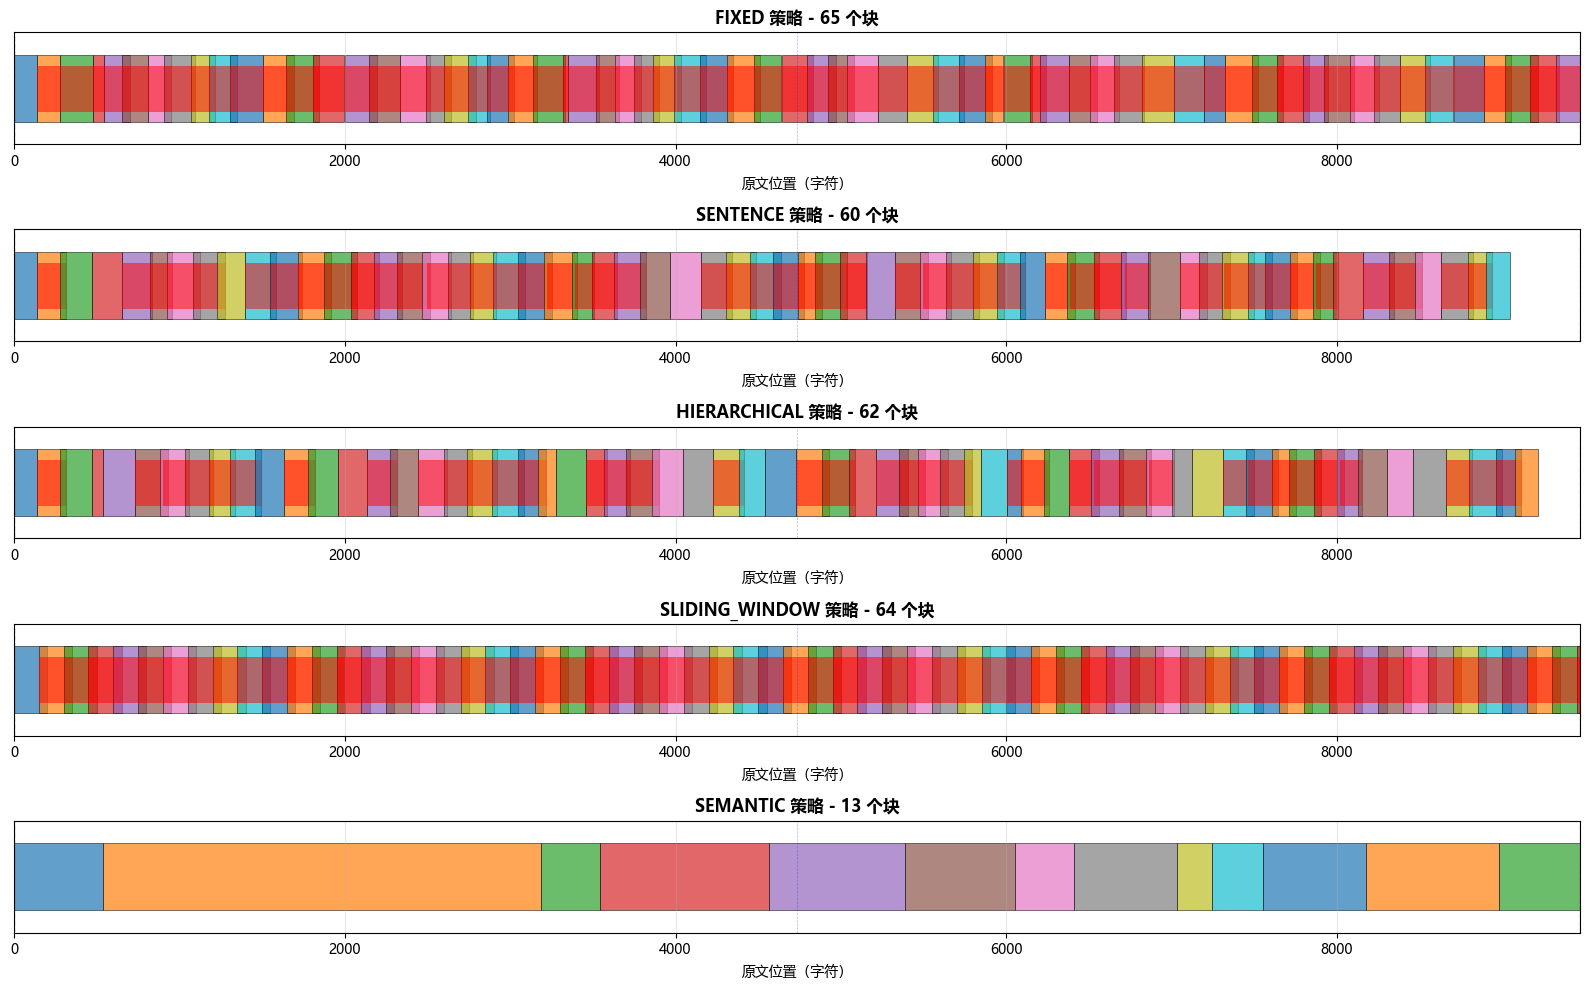


说明:
- 每个彩色条代表一个chunk在原文中的位置
- 红色区域表示重叠部分
- 绿色虚线：文档开头
- 红色虚线：文档结尾


In [ ]:
# 绘制块位置分布图
fig, axes = plt.subplots(len(results), 1, figsize=(16, 2 * len(results)))
if len(results) == 1:
    axes = [axes]

original_length = len(test_doc.page_content)

for idx, (strategy, chunks) in enumerate(results.items()):
    ax = axes[idx]
    
    # 收集块的位置信息
    chunk_ranges = []
    for i, chunk in enumerate(chunks):
        start = None
        end = None
        
        if 'start_index' in chunk.metadata:
            start = chunk.metadata['start_index']
            end = start + len(chunk.page_content)
        elif 'window_start' in chunk.metadata:
            start = chunk.metadata['window_start']
            end = chunk.metadata['window_end']
        else:
            # 对于没有位置信息的策略，使用累加方式估算
            if i == 0:
                start = 0
            else:
                # 简单估算：假设前一个块的结束位置
                prev_end = chunk_ranges[-1][1] if chunk_ranges else 0
                start = prev_end - (chunk_ranges[-1][2] if chunk_ranges else 0)  # 减去重叠
            end = start + len(chunk.page_content)
        
        if start is not None and end is not None:
            chunk_ranges.append((start, end, chunk.metadata.get('chunk_overlap', 0)))
    
    # 绘制每个块的位置条
    for i, (start, end, overlap) in enumerate(chunk_ranges):
        # 主块区域
        ax.barh(0, end - start, left=start, height=0.6, alpha=0.7, 
                color=plt.cm.tab10(i % 10), edgecolor='black', linewidth=0.5)
        
        # 如果有重叠，用不同颜色标记重叠部分
        if overlap > 0 and i > 0:
            prev_end = chunk_ranges[i-1][1]
            overlap_start = max(start, prev_end - overlap)
            if overlap_start < end:
                ax.barh(0, end - overlap_start, left=overlap_start, height=0.4,
                       alpha=0.5, color='red', edgecolor='red', linewidth=0.5)
    
    ax.set_xlim(0, original_length)
    ax.set_ylim(-0.5, 0.5)
    ax.set_xlabel("原文位置（字符）", fontsize=10)
    ax.set_title(f"{strategy.upper()} 策略 - {len(chunks)} 个块", fontsize=12, fontweight='bold')
    ax.set_yticks([])
    ax.grid(True, alpha=0.3, axis='x')
    
    # 添加关键位置标记（文档开头、中间、结尾）
    ax.axvline(0, color='green', linestyle='--', alpha=0.5, linewidth=1)
    ax.axvline(original_length, color='red', linestyle='--', alpha=0.5, linewidth=1)
    if original_length > 2000:
        ax.axvline(original_length // 2, color='blue', linestyle='--', alpha=0.3, linewidth=0.5)

plt.tight_layout()
plt.show()

print("\n说明:")
print("- 每个彩色条代表一个chunk在原文中的位置")
print("- 红色区域表示重叠部分")
print("- 绿色虚线：文档开头")
print("- 红色虚线：文档结尾")


## 详细对比

查看每个策略生成的块的具体内容。


In [ ]:
# 选择要详细查看的策略
selected_strategy = "fixed"  # 可以修改为其他策略

if selected_strategy in results:
    chunks = results[selected_strategy]
    print(f"\n{selected_strategy.upper()} 策略 - 所有块详情:\n")
    print("="*80)
    
    for i, chunk in enumerate(chunks, 1):
        print(f"\n块 {i}:")
        print(f"长度: {len(chunk.page_content)} 字符")
        print(f"元数据: {chunk.metadata}")
        print(f"内容:\n{chunk.page_content}")
        print("-"*80)
else:
    print(f"策略 '{selected_strategy}' 不存在")



FIXED 策略 - 所有块详情:


块 1:
长度: 141 字符
元数据: {'producer': 'Qt 4.8.7', 'creator': 'wkhtmltopdf 0.12.6.1', 'creationdate': '2026-02-19T13:10:08+08:00', 'title': '人工智能时代真正重要的技能：你的品味', 'source': 'F:\\AIhub\\Agent-RAG\\WXdown-RAG\\data\\WXhub\\AI寒武纪\\pdf\\2026-02-19-人工智能时代真正重要的技能：你的品味.pdf', 'total_pages': 8, 'page': 0, 'page_label': '1', 'channel': 'AI寒武纪', 'date': '2026-02-19', 'url': 'https://mp.weixin.qq.com/s/zMxwBfn2Kvn3EgPfRvYOWw', 'msg_link': 'https://mp.weixin.qq.com/s/zMxwBfn2Kvn3EgPfRvYOWw', 'create_time': '2026-02-19 12:05', 'start_index': 0, 'chunk_strategy': 'fixed_size', 'chunk_size': 200, 'chunk_overlap': 50}
内容:
人工智能时代真正重要的技能：你的品味2026 年 2 月 19 日 12:05 AI 寒武纪 ↑ 阅读之前记得关注 + 星标  ️ ，  ，每天才能第一时间接收到更新 在人工智能时代，品味将变得更加重要。当任何人都能制作任何东西时，真正的区别在 在人工智能时代，品味将变得更加重要
--------------------------------------------------------------------------------

块 2:
长度: 139 字符
元数据: {'producer': 'Qt 4.8.7', 'creator': 'wkhtmltopdf 0.12.6.1', 'creationdate': '2026-02-19T13:10:08+08:00', 'title': '人工智能时代真正重要的技

## 结论

根据对比分析，选择最适合你数据集的切分策略。

### 当前推荐实践：

- **fixed**: 通用场景首选，速度快，结果稳定，适合作为默认基线
- **sentence**: 适合强调句子完整性的问答场景
- **semantic**: 适合需要语义边界的场景，但建议配合当前项目的 `mixed` 分句模式使用
- **hierarchical**: 适合文档段落结构较明显的数据
- **sliding_window**: 适合需要更多上下文重叠的检索场景

### 语义切分最佳实践：

- 默认使用 `sentence_split_mode="mixed"`
- 显式指定 `breakpoint_threshold_type="percentile"`
- 优先通过项目配置控制语义切分，而不是在 notebook 里手工构造 splitter
- 如果 PDF/OCR 噪声较多，再进一步尝试 `custom` 正则
